# LSTM-GATv2 End-to-End (Step 1a)

Per-timestep LSTM-GATv2 with training + architecture fixes.

**Key improvements over `lstm_gat_end_to_end.ipynb`:**
- GATv2 dynamic attention (truly pairwise scores)
- Separate LSTM dropout (0.3) and attention dropout (0.1)
- No LayerNormalization after GAT (matches GCN)
- Larger dimensions: LSTM hidden=32, GAT units=16, heads=4
- Less aggressive gradient clipping: 1.0 vs 0.01
- Batch size 128 for more stable Sharpe estimates

**Architecture**: Shared LSTM → GATv2 (full attention, per timestep) → Position output

## 1. Setup

In [25]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [26]:
import os
import sys

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annual_return, annual_volatility, calmar_ratio,
)

import random
random.seed(40)
np.random.seed(40)

import tensorflow as tf
tf.random.set_seed(40)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [ ]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023

VOL_TARGET = 0.15

# Stride: 20 = non-overlapping independent windows
TRAIN_STRIDE = 20

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# GATv2 Hyperparameters (all changed from original)
HIDDEN_LAYER_SIZE = 32   # was 10
GAT_UNITS = 16           # was 8
ATTN_HEADS = 4           # was 2
LSTM_DROPOUT = 0.3       # was 0.5 (shared)
ATTN_DROPOUT = 0.1       # was 0.5 (shared)
LEARNING_RATE = 0.001    # was 0.0005
MAX_GRADIENT_NORM = 1.0  # was 0.01
NUM_GAT_LAYERS = 1  
BATCH_SIZE = 64         # was 32

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nModel: LSTM-GATv2 End-to-End (Step 1a)")
print(f"  Stride: {TRAIN_STRIDE}")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {LSTM_DROPOUT}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print(f"  Attention dropout: {ATTN_DROPOUT}")
print(f"  LR: {LEARNING_RATE}, clip norm: {MAX_GRADIENT_NORM}")
print(f"  Batch size: {BATCH_SIZE}")

Train: 2011-2017
Test:  2017-2023

Model: LSTM-GATv2 End-to-End (Step 1a)
  Stride: 20
  LSTM hidden: 32, dropout: 0.3
  GAT units: 16, heads: 4, layers: 1
  Attention dropout: 0.1
  LR: 0.001, clip norm: 1.0
  Batch size: 64


## 3. Helper Functions

In [29]:
def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        return daily_returns * (target_vol / current_vol)
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    return {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled = calc_vol_scaled_returns(daily_returns, target_vol)
    return calc_metrics(scaled, name + " (Vol-Norm)"), scaled


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict]).set_index('Strategy')
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))

    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    yearly_data = {name: calc_yearly_sharpes(returns) for name, returns in daily_returns_dict.items()}
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading

In [30]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/features.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
#features_path = "data/straddle_features/features.csv"
features_path = "/content/drive/MyDrive/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88


In [32]:
from gml.graph_model_inputs import GraphModelFeatures

features = GraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
    train_valid_sliding=True,
)

print("Feature generator created (sliding windows enabled).")

no lags


train _batch
After final stacking and culling:
inputs.shape: (1131, 88, 20, 10)
outputs.shape: (1131, 88, 20, 1)
active_entries.shape: (1131, 88, 20, 1)
identifier.shape: (1131, 88, 20, 1)
date.shape: (1131, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (269, 88, 20, 10)
outputs.shape: (269, 88, 20, 1)
active_entries.shape: (269, 88, 20, 1)
identifier.shape: (269, 88, 20, 1)
date.shape: (269, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Feature generator created (sliding windows enabled).


In [33]:
# Apply stride for independent non-overlapping windows
train_data = {k: v[::TRAIN_STRIDE] for k, v in features.train.items()}
valid_data = {k: v[::TRAIN_STRIDE] for k, v in features.valid.items()}
test_data = features.test_sliding  # Test always uses stride=1

print(f"Stride: {TRAIN_STRIDE}")
print(f"\nTraining data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")
print(f"\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")

Stride: 20

Training data:
  inputs: (57, 88, 20, 10)
  outputs: (57, 88, 20, 1)

Validation data:
  inputs: (14, 88, 20, 10)

Test data:
  inputs: (1400, 88, 20, 10)


## 5. Model Definition

In [34]:
from gml.graph_attention_v2 import build_lstm_gat_e2e_v2

num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"Building LSTM-GATv2 E2E model (Step 1a):")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")

model = build_lstm_gat_e2e_v2(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    hidden_layer_size=HIDDEN_LAYER_SIZE,
    gat_units=GAT_UNITS,
    attn_heads=ATTN_HEADS,
    lstm_dropout=LSTM_DROPOUT,
    attn_dropout=ATTN_DROPOUT,
    learning_rate=LEARNING_RATE,
    max_gradient_norm=MAX_GRADIENT_NORM,
    num_gat_layers=NUM_GAT_LAYERS,
)

print(f"\nTotal parameters: {model.count_params():,}")

Building LSTM-GATv2 E2E model (Step 1a):
  num_tickers: 88
  time_steps: 20
  input_size: 10

Total parameters: 10,209


## 6. Training

In [35]:
X_train = train_data['inputs']
y_train = train_data['outputs']
w_train = train_data['active_entries']

X_valid = valid_data['inputs']
y_valid = valid_data['outputs']
w_valid = valid_data['active_entries']

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")

Training samples: 57
Validation samples: 14


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 60)
print("Training LSTM-GATv2 E2E (Step 1a)")
print(f"  Stride: {TRAIN_STRIDE} ({X_train.shape[0]} training samples)")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, GAT: {GAT_UNITS}x{ATTN_HEADS}")
print(f"  Dropout: LSTM={LSTM_DROPOUT}, Attn={ATTN_DROPOUT}")
print(f"  LR: {LEARNING_RATE}, clip: {MAX_GRADIENT_NORM}, batch: {BATCH_SIZE}")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GATv2 E2E (Step 1a)
  Stride: 20 (57 training samples)
  LSTM hidden: 32, GAT: 16x4
  Dropout: LSTM=0.3, Attn=0.1
  LR: 0.001, clip: 1.0, batch: 64
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 250s 250s/step - loss: -0.3613 - val_loss: -0.6519
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step - loss: -0.3794 - val_loss: -0.6858
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: -0.3894 - val_loss: -0.7166
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - loss: -0.4771 - val_loss: -0.7460
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step - loss: -0.4947 - val_loss: -0.7744
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step - loss: -0.5298 - val_loss: -0.8010
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - loss: -0.5034 - val_loss: -0.8277
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - loss: -0.5669 - val_loss: -0.8550
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step - loss: -0.5913 - val_loss: -0.8812
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - los

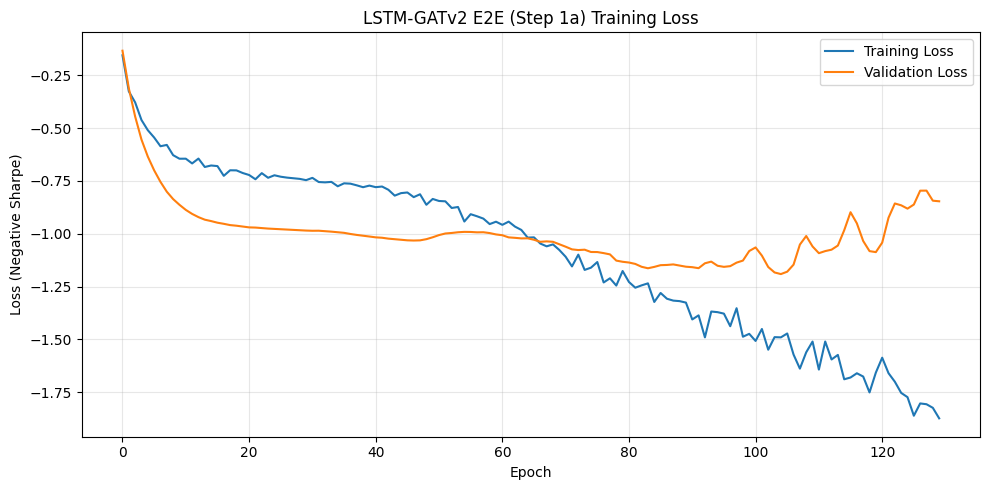

Epochs trained: 130
Best val loss: -1.1905


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title('LSTM-GATv2 E2E (Step 1a) Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

## 7. Evaluation

In [ ]:
X_test = test_data['inputs']
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step 
Predictions shape: (1400, 88, 20, 1)
Test outputs shape: (1400, 88, 20, 1)


In [ ]:
# Extract last timestep only (no double-counting)
positions = predictions[:, :, -1, 0].reshape(-1)
returns = test_data['outputs'][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

dates = test_data['date'][:, :, -1, 0].reshape(-1)
identifiers = test_data['identifier'][:, :, -1, 0].reshape(-1)

results_df = pd.DataFrame({
    'time': dates, 'identifier': identifiers,
    'position': positions, 'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,0.205040,-0.009874,-0.002025
1,2017-01-03,ABT,0.358169,-0.002442,-0.000875
2,2017-01-03,ACN,-0.027040,-0.008236,0.000223
3,2017-01-03,ADBE,0.246638,-0.010764,-0.002655
4,2017-01-03,AIG,0.616628,-0.003832,-0.002363


In [ ]:
daily_returns = calc_daily_returns(results_df)

print("\n" + "=" * 60)
print("LSTM-GATv2 E2E (Step 1a) Results (Raw)")
print("=" * 60)

metrics_raw = calc_metrics(daily_returns, "LSTM-GATv2 E2E")
display_metrics(metrics_raw)

print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, "LSTM-GATv2 E2E", VOL_TARGET)
display_metrics(metrics_norm)

print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe_val in yearly_sharpes.items():
    print(f"  {year}: {sharpe_val:.4f}")


LSTM-GATv2 E2E (Step 1a) Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GATv2 E2E,3.05%,2.87%,1.061,1.461,3.88%,0.786,56.57%,0.973



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GATv2 E2E (Vol-Norm),15.93%,15.00%,1.061,1.461,19.07%,0.835,56.57%,0.973



Yearly Sharpe Ratios:
  2017: 3.0809
  2018: -0.2664
  2019: 1.7895
  2020: 0.4208
  2021: 0.7950
  2022: 1.5160


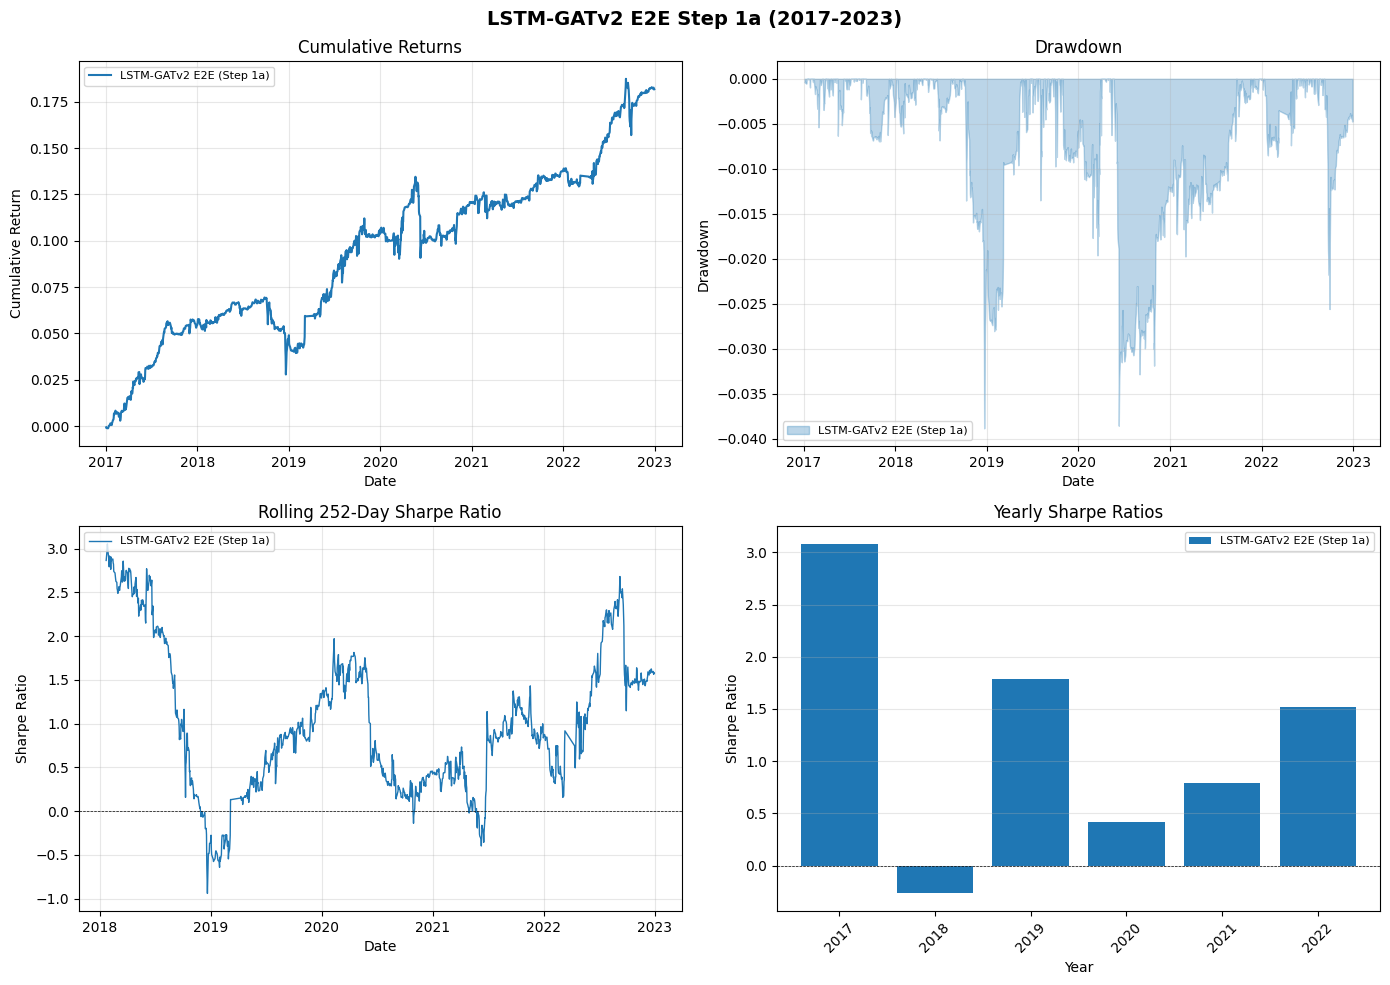

In [ ]:
all_daily_returns = {'LSTM-GATv2 E2E (Step 1a)': daily_returns}
plot_results(all_daily_returns, f"LSTM-GATv2 E2E Step 1a ({TEST_START}-{TEST_END})")

## 8. Attention Analysis

In [ ]:
from gml.graph_attention_v2 import extract_attention_weights_v2

# Extract attention from a subset of test windows
n_samples = min(50, X_test.shape[0])
sample_indices = np.linspace(0, X_test.shape[0] - 1, n_samples, dtype=int)
X_sample = X_test[sample_indices]

attn_weights = extract_attention_weights_v2(model, X_sample, gat_layer_name="gat_v2_0")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"  (samples, heads, nodes, nodes)")

# Average across heads
attn_avg = attn_weights.mean(axis=1)  # (samples, nodes, nodes)

# Check attention entropy (should be < log(88) = 4.48 for non-degenerate)
entropy = -np.sum(attn_avg * np.log(attn_avg + 1e-9), axis=-1)  # (samples, nodes)
mean_entropy = entropy.mean()
max_entropy = np.log(attn_avg.shape[-1])
print(f"\nAttention entropy: {mean_entropy:.3f} (uniform = {max_entropy:.3f})")
print(f"Entropy ratio: {mean_entropy / max_entropy:.3f} (lower = more focused)")

Attention weights shape: (50, 4, 88, 88)
  (samples, heads, nodes, nodes)

Attention entropy: 4.442 (uniform = 4.477)
Entropy ratio: 0.992 (lower = more focused)


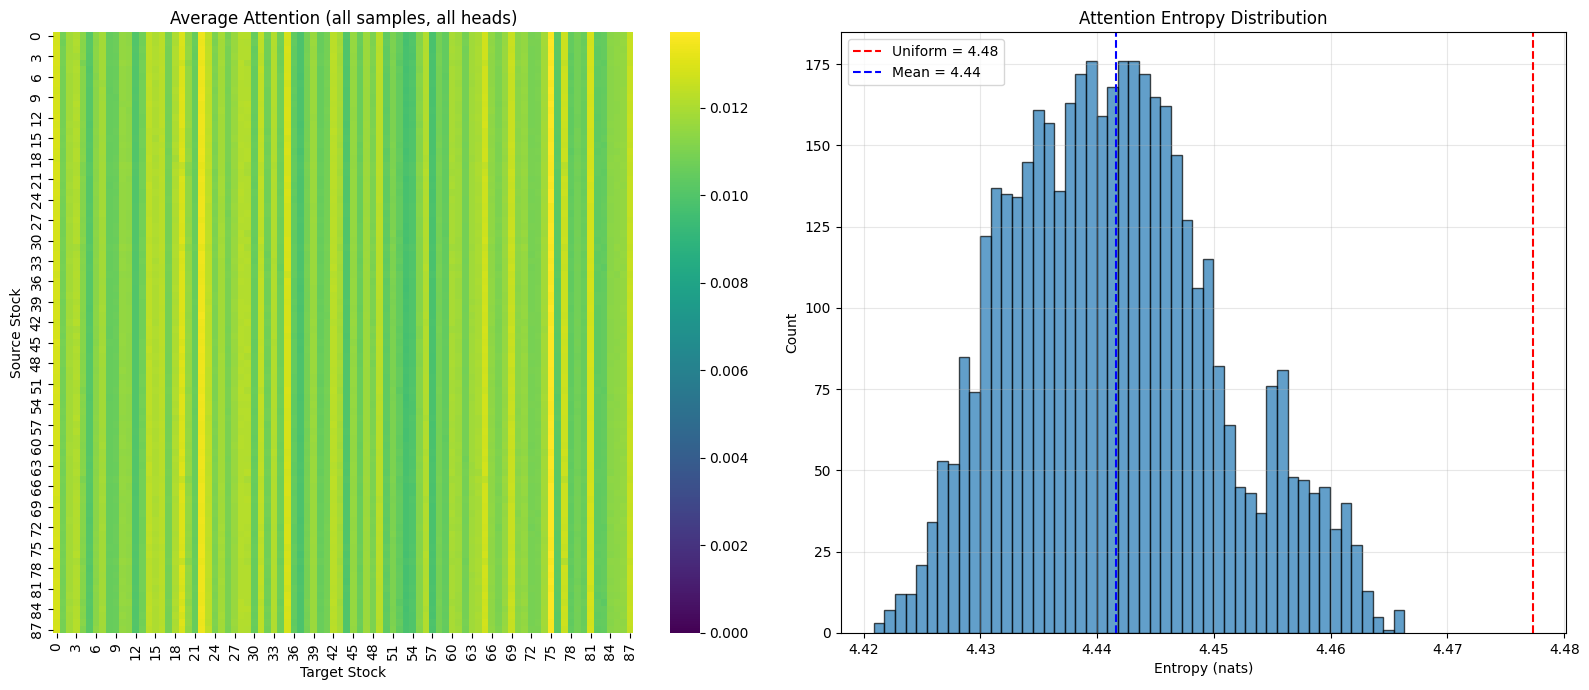

In [ ]:
# Plot average attention heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Overall average attention
avg_attn = attn_avg.mean(axis=0)  # (nodes, nodes)
sns.heatmap(avg_attn, ax=axes[0], cmap='viridis', vmin=0)
axes[0].set_title('Average Attention (all samples, all heads)')
axes[0].set_xlabel('Target Stock')
axes[0].set_ylabel('Source Stock')

# Attention entropy distribution
axes[1].hist(entropy.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=max_entropy, color='red', linestyle='--', label=f'Uniform = {max_entropy:.2f}')
axes[1].axvline(x=mean_entropy, color='blue', linestyle='--', label=f'Mean = {mean_entropy:.2f}')
axes[1].set_xlabel('Entropy (nats)')
axes[1].set_ylabel('Count')
axes[1].set_title('Attention Entropy Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8b. Interactive Graph Visualization

In [72]:
# Extract attention for ALL test windows (for interactive graph + connectivity)
print(f"Extracting attention for all {X_test.shape[0]} test windows...")
all_attn = extract_attention_weights_v2(model, X_test, gat_layer_name="gat_v2_0")
all_graphs_avg = all_attn.mean(axis=1)  # (N, 88, 88) - avg across heads
print(f"Done: {all_graphs_avg.shape}")

# Test dates for slider
test_dates_arr = pd.to_datetime(test_data['date'][:, 0, -1, 0])
print(f"Date range: {test_dates_arr[0].date()} to {test_dates_arr[-1].date()}")

Extracting attention for all 1400 test windows...
Done: (1400, 88, 88)
Date range: 2017-01-03 to 2022-12-30


In [73]:
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from settings.default import ALL_TICKERS, BBG_SECTORS

SECTOR_COLORS = {
    "Information Technology": "#1f77b4",
    "Healthcare": "#2ca02c",
    "Financials": "#ff7f0e",
    "Consumer Discretionary": "#d62728",
    "Consumer Staples": "#9467bd",
    "Industrials": "#8c564b",
    "Communication Services": "#e377c2",
    "Energy": "#7f7f7f",
    "Utilities": "#bcbd22",
    "Real Estate": "#17becf",
}

tickers = sorted(ALL_TICKERS)
G_ref = nx.Graph()
for t in tickers:
    G_ref.add_node(t, sector=BBG_SECTORS.get(t, "Unknown"))

fixed_pos = nx.spring_layout(G_ref, k=2.5, iterations=100, seed=42)
node_colors = [SECTOR_COLORS.get(BBG_SECTORS.get(t, "Unknown"), "#cccccc") for t in tickers]

# Rolling Sharpe for bottom panel
rolling_sharpe = daily_returns.rolling(252).mean() / daily_returns.rolling(252).std() * np.sqrt(252)

print(f"Ready: {len(all_graphs_avg)} graphs, {len(test_dates_arr)} dates")

Ready: 1400 graphs, 1400 dates


In [78]:
EDGE_THRESHOLD = 0.0#12#2  # 1/88 ≈ 0.0114, so 0.02 = "above uniform"

output_widget = widgets.Output()

def update_graph(window_idx):
    with output_widget:
        clear_output(wait=True)

        fig, (ax_graph, ax_sharpe) = plt.subplots(
            2, 1, figsize=(14, 16),
            gridspec_kw={'height_ratios': [3, 1]}
        )

        # --- Top: Learned attention graph ---
        adj = all_graphs_avg[window_idx]
        date_str = str(test_dates_arr[window_idx].date()) if window_idx < len(test_dates_arr) else "N/A"

        G = nx.Graph()
        for t in tickers:
            G.add_node(t)

        n = len(tickers)
        for i in range(n):
            for j in range(i + 1, n):
                w = (adj[i, j] + adj[j, i]) / 2
                if w > EDGE_THRESHOLD:
                    G.add_edge(tickers[i], tickers[j], weight=w)

        edges = G.edges(data=True)
        if len(edges) > 0:
            weights = [d['weight'] for _, _, d in edges]
            max_w = max(weights) if weights else 1.0
            for (u, v, d) in edges:
                w = d['weight']
                width = 2.0 * w / max_w
                alpha = 0.3 + 0.7 * w / max_w
                x = [fixed_pos[u][0], fixed_pos[v][0]]
                y = [fixed_pos[u][1], fixed_pos[v][1]]
                ax_graph.plot(x, y, color='gray', linewidth=width, alpha=alpha, zorder=1)

        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors,
                               node_size=600, alpha=0.9, ax=ax_graph)
        nx.draw_networkx_labels(G, fixed_pos, font_size=6, font_weight='bold', ax=ax_graph)

        num_edges = G.number_of_edges()
        ax_graph.set_title(
            f"Learned Attention Graph at {date_str}  |  {num_edges} edges (threshold={EDGE_THRESHOLD})",
            fontsize=14, fontweight='bold'
        )
        ax_graph.axis('off')

        # --- Bottom: Rolling Sharpe with date marker ---
        ax_sharpe.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color='blue')
        ax_sharpe.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        if window_idx < len(test_dates_arr):
            ax_sharpe.axvline(x=test_dates_arr[window_idx], color='red', linewidth=2, alpha=0.8)
        ax_sharpe.set_title('Rolling 252-Day Sharpe Ratio', fontsize=12)
        ax_sharpe.set_xlabel('Date')
        ax_sharpe.set_ylabel('Sharpe')
        ax_sharpe.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

slider = widgets.IntSlider(
    min=0, max=len(all_graphs_avg) - 1, step=1, value=0,
    description='Window:',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

widgets.interactive(update_graph, window_idx=slider)
display(slider, output_widget)
update_graph(0)

IntSlider(value=0, continuous_update=False, description='Window:', layout=Layout(width='80%'), max=1399)

Output()

## 8c. Graph Connectivity Over Time

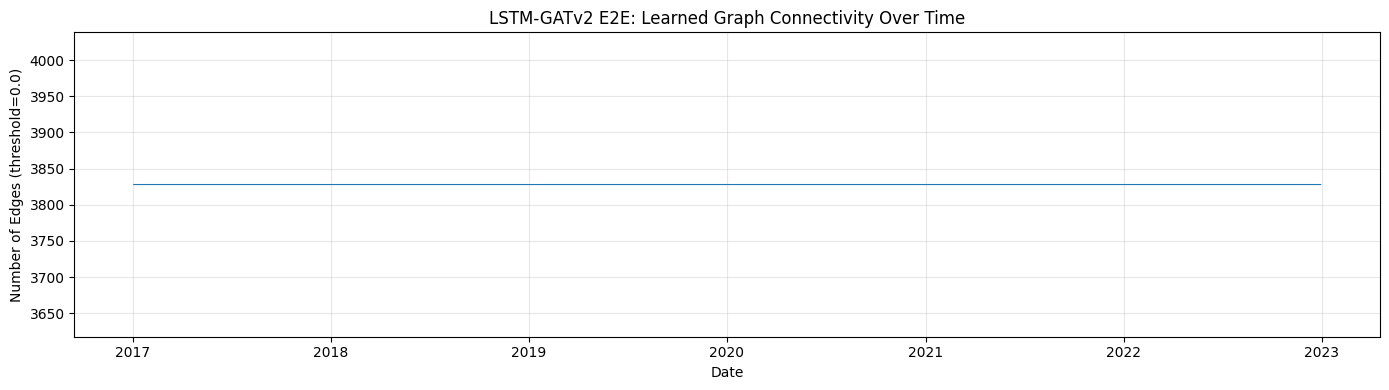

Edge statistics (threshold=0.0):
  Mean: 3828.0
  Std:  0.0
  Min:  3828
  Max:  3828


In [79]:
def plot_connectivity_over_time(graphs, dates, threshold, title=""):
    """Plot number of edges (above threshold) at each test window."""
    num_edges = []
    for g in graphs:
        sym = (g + g.T) / 2
        edges = ((sym > threshold).sum() - sym.shape[0]) / 2  # exclude self-loops
        num_edges.append(edges)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, num_edges, linewidth=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel(f'Number of Edges (threshold={threshold})')
    ax.set_title(title or f'Graph Connectivity Over Time (threshold={threshold})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Edge statistics (threshold={threshold}):")
    print(f"  Mean: {np.mean(num_edges):.1f}")
    print(f"  Std:  {np.std(num_edges):.1f}")
    print(f"  Min:  {np.min(num_edges):.0f}")
    print(f"  Max:  {np.max(num_edges):.0f}")

plot_connectivity_over_time(
    all_graphs_avg, test_dates_arr, EDGE_THRESHOLD,
    "LSTM-GATv2 E2E: Learned Graph Connectivity Over Time"
)

## 8d. Graph Statistics Over Time

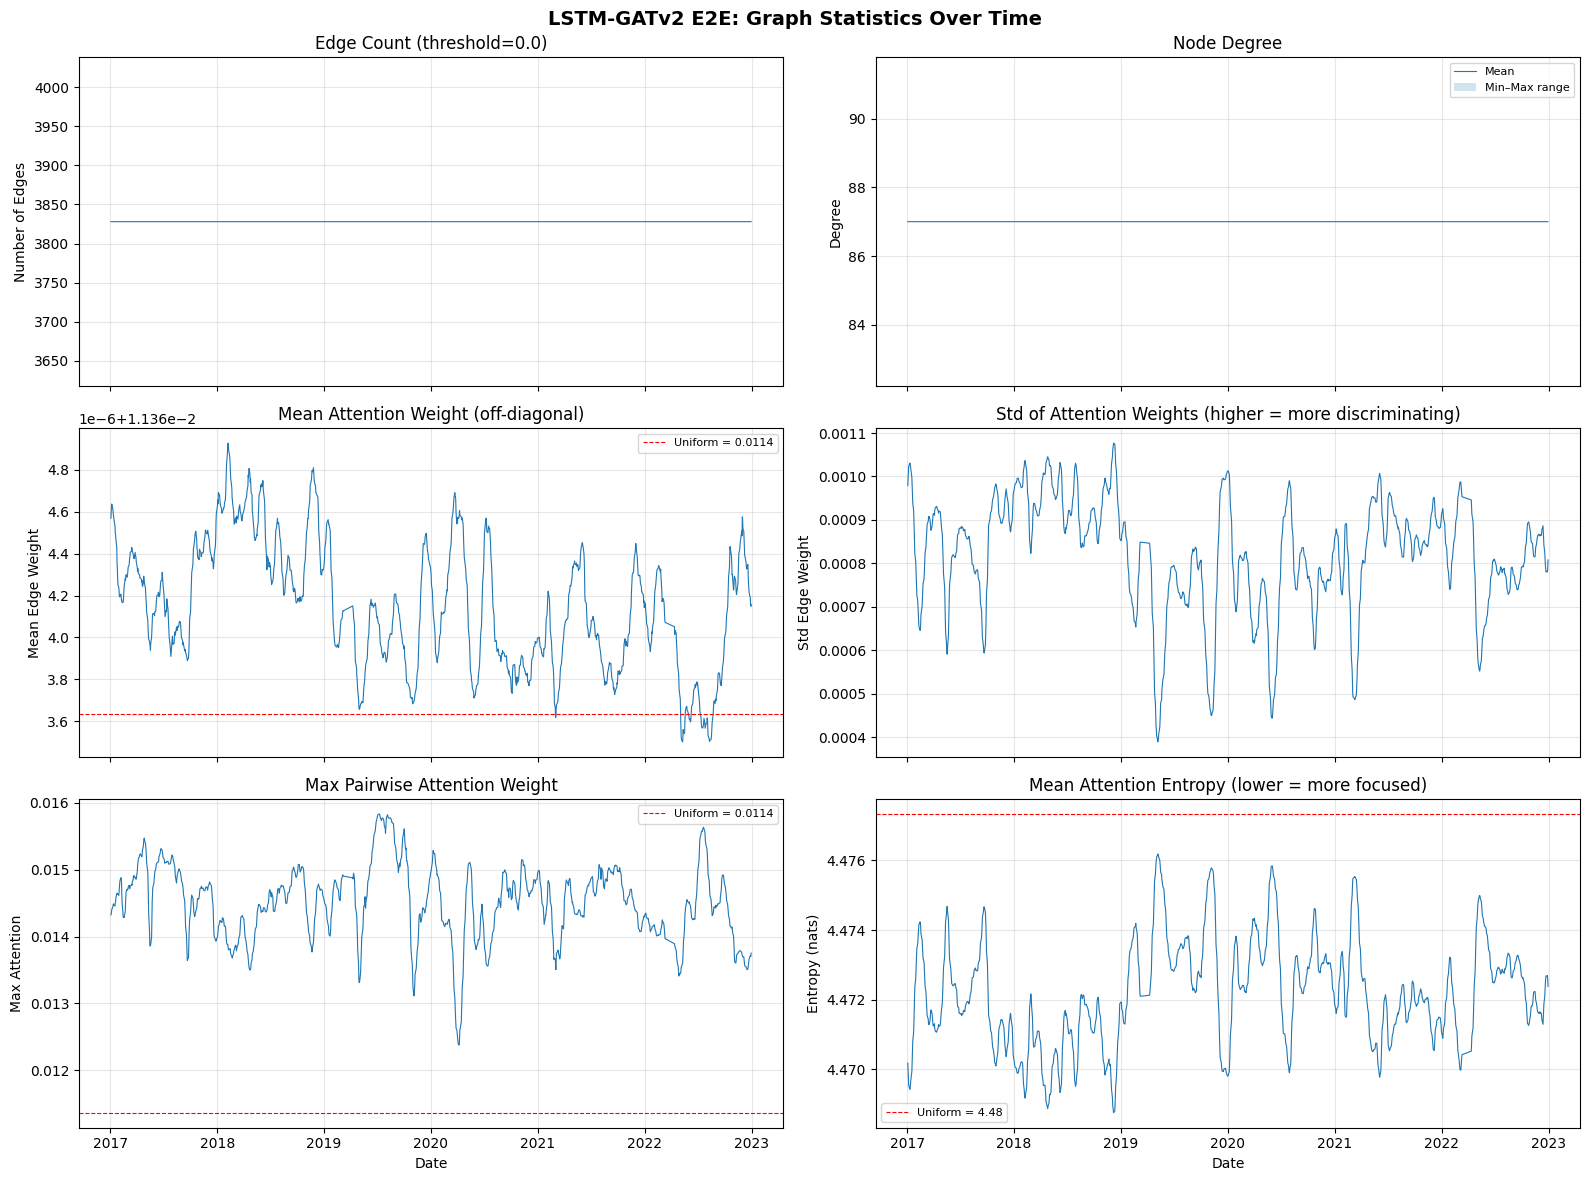


Graph Statistics Summary:
  num_edges           : mean=3828.0000, std=0.0000, min=3828.0000, max=3828.0000
  mean_degree         : mean=87.0000, std=0.0000, min=87.0000, max=87.0000
  max_degree          : mean=87.0000, std=0.0000, min=87.0000, max=87.0000
  min_degree          : mean=87.0000, std=0.0000, min=87.0000, max=87.0000
  mean_edge_weight    : mean=0.0114, std=0.0000, min=0.0114, max=0.0114
  std_edge_weight     : mean=0.0008, std=0.0001, min=0.0004, max=0.0011
  mean_entropy        : mean=4.4722, std=0.0015, min=4.4687, max=4.4762
  max_attn            : mean=0.0145, std=0.0006, min=0.0124, max=0.0158


In [80]:
def compute_graph_statistics(graphs, threshold):
    """Compute per-window graph statistics from attention matrices."""
    stats = {
        'num_edges': [], 'mean_degree': [], 'max_degree': [], 'min_degree': [],
        'mean_edge_weight': [], 'std_edge_weight': [],
        'mean_entropy': [], 'max_attn': [],
    }
    n = graphs.shape[-1]
    uniform_entropy = np.log(n)

    for g in graphs:
        sym = (g + g.T) / 2
        np.fill_diagonal(sym, 0)

        # Edge statistics (above threshold)
        mask = sym > threshold
        edge_count = mask.sum() / 2
        degree = mask.sum(axis=1)
        stats['num_edges'].append(edge_count)
        stats['mean_degree'].append(degree.mean())
        stats['max_degree'].append(degree.max())
        stats['min_degree'].append(degree.min())

        # Edge weight statistics (all off-diagonal)
        off_diag = sym[~np.eye(n, dtype=bool)]
        stats['mean_edge_weight'].append(off_diag.mean())
        stats['std_edge_weight'].append(off_diag.std())
        stats['max_attn'].append(off_diag.max())

        # Entropy (from original asymmetric attention)
        ent = -np.sum(g * np.log(g + 1e-9), axis=-1)  # (nodes,)
        stats['mean_entropy'].append(ent.mean())

    return {k: np.array(v) for k, v in stats.items()}, uniform_entropy


graph_stats, uniform_ent = compute_graph_statistics(all_graphs_avg, EDGE_THRESHOLD)

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# Edges over time
axes[0, 0].plot(test_dates_arr, graph_stats['num_edges'], linewidth=0.8)
axes[0, 0].set_ylabel('Number of Edges')
axes[0, 0].set_title(f'Edge Count (threshold={EDGE_THRESHOLD})')
axes[0, 0].grid(True, alpha=0.3)

# Mean degree
axes[0, 1].plot(test_dates_arr, graph_stats['mean_degree'], linewidth=0.8, label='Mean')
axes[0, 1].fill_between(test_dates_arr, graph_stats['min_degree'], graph_stats['max_degree'],
                         alpha=0.2, label='Min–Max range')
axes[0, 1].set_ylabel('Degree')
axes[0, 1].set_title('Node Degree')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Mean edge weight
axes[1, 0].plot(test_dates_arr, graph_stats['mean_edge_weight'], linewidth=0.8)
axes[1, 0].axhline(y=1/all_graphs_avg.shape[-1], color='red', linestyle='--',
                    linewidth=0.8, label=f'Uniform = {1/all_graphs_avg.shape[-1]:.4f}')
axes[1, 0].set_ylabel('Mean Edge Weight')
axes[1, 0].set_title('Mean Attention Weight (off-diagonal)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Std edge weight
axes[1, 1].plot(test_dates_arr, graph_stats['std_edge_weight'], linewidth=0.8)
axes[1, 1].set_ylabel('Std Edge Weight')
axes[1, 1].set_title('Std of Attention Weights (higher = more discriminating)')
axes[1, 1].grid(True, alpha=0.3)

# Max attention
axes[2, 0].plot(test_dates_arr, graph_stats['max_attn'], linewidth=0.8)
axes[2, 0].axhline(y=1/all_graphs_avg.shape[-1], color='red', linestyle='--',
                    linewidth=0.8, label=f'Uniform = {1/all_graphs_avg.shape[-1]:.4f}')
axes[2, 0].set_ylabel('Max Attention')
axes[2, 0].set_title('Max Pairwise Attention Weight')
axes[2, 0].set_xlabel('Date')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)

# Entropy
axes[2, 1].plot(test_dates_arr, graph_stats['mean_entropy'], linewidth=0.8)
axes[2, 1].axhline(y=uniform_ent, color='red', linestyle='--',
                    linewidth=0.8, label=f'Uniform = {uniform_ent:.2f}')
axes[2, 1].set_ylabel('Entropy (nats)')
axes[2, 1].set_title('Mean Attention Entropy (lower = more focused)')
axes[2, 1].set_xlabel('Date')
axes[2, 1].legend(fontsize=8)
axes[2, 1].grid(True, alpha=0.3)

plt.suptitle('LSTM-GATv2 E2E: Graph Statistics Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print(f"\nGraph Statistics Summary:")
for k, v in graph_stats.items():
    print(f"  {k:20s}: mean={v.mean():.4f}, std={v.std():.4f}, min={v.min():.4f}, max={v.max():.4f}")

## 9. Position Analysis

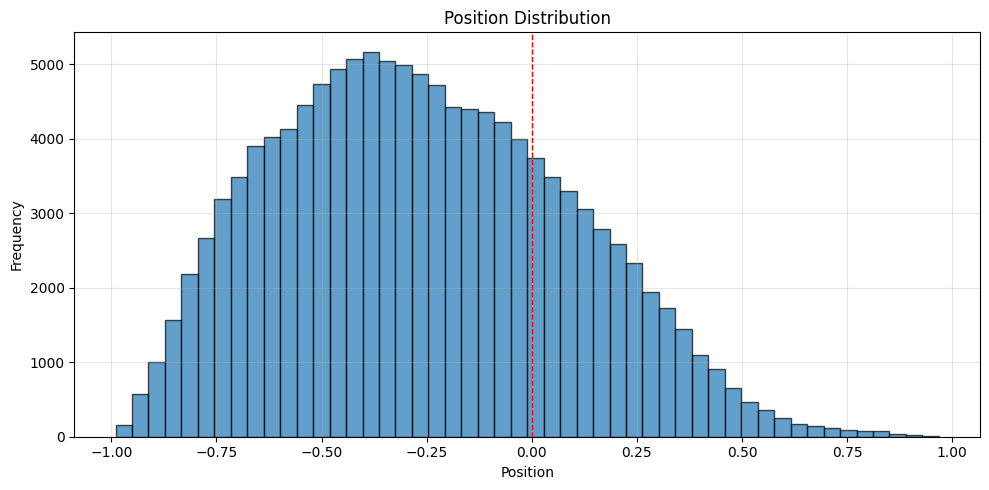

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(results_df['position'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.title('Position Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Save Results

In [ ]:
results_dir = f"results/lstm_gat_e2e_v2_u{GAT_UNITS}_h{ATTN_HEADS}/{TEST_START}-{TEST_END}"
os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)
pd.DataFrame([metrics_raw]).to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)
pd.DataFrame([metrics_norm]).to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)
pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe']).to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gat_e2e_v2_u16_h4/2017-2023


## 11. Summary

In [ ]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"\nModel: LSTM-GATv2 End-to-End (Step 1a)")
print(f"  GATv2 dynamic attention (truly pairwise)")
print(f"  No LayerNorm, split dropout, larger dims")
print(f"\nHyperparameters:")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {LSTM_DROPOUT}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print(f"  Attn dropout: {ATTN_DROPOUT}")
print(f"  LR: {LEARNING_RATE}, clip norm: {MAX_GRADIENT_NORM}")
print(f"  Batch size: {BATCH_SIZE}, stride: {TRAIN_STRIDE}")
print(f"\nTraining: {TRAIN_START}-{TEST_START}")
print(f"Test:     {TEST_START}-{TEST_END}")
print(f"\nPerformance (Raw):")
print(f"  Sharpe: {metrics_raw['Sharpe']:.3f}")
print(f"  Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Vol:    {metrics_raw['Vol.']:.2%}")
print(f"  Sortino: {metrics_raw['Sortino']:.3f}")
print(f"  Max DD: {metrics_raw['Max DD']:.2%}")
print(f"\nAttention entropy: {mean_entropy:.3f} / {max_entropy:.3f} (ratio: {mean_entropy/max_entropy:.3f})")

EXPERIMENT SUMMARY

Model: LSTM-GATv2 End-to-End (Step 1a)
  GATv2 dynamic attention (truly pairwise)
  No LayerNorm, split dropout, larger dims

Hyperparameters:
  LSTM hidden: 32, dropout: 0.3
  GAT units: 16, heads: 4, layers: 2
  Attn dropout: 0.1
  LR: 0.001, clip norm: 1.0
  Batch size: 64, stride: 20

Training: 2011-2017
Test:     2017-2023

Performance (Raw):
  Sharpe: 1.061
  Return: 3.05%
  Vol:    2.87%
  Sortino: 1.461
  Max DD: 3.88%

Attention entropy: 4.442 / 4.477 (ratio: 0.992)
